## Setup

In [75]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Set up the working environment:

In [76]:
# To ensure reproducibility
seed = 42

# Load basic libraries
import os
import sys
from pathlib import Path

# If the session is running local
root_path = Path(os.path.abspath(".."))

# Add path to Python's system
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

# Create file paths
file_path = root_path / 'data' / 'clean' / 'clinical_data.parquet'
results_path = root_path / 'results' / 'models' / 'whole_data'

Load libraries:

In [77]:
# DATA WRANGLING AND STATISTICS
import pandas as pd
import numpy as np
from scipy.stats import randint, uniform, loguniform

# DATA PREPROCESSING
from sklearn.pipeline import Pipeline

# HYPERPARAMETER TUNING
import optuna
from optuna.integration import OptunaSearchCV
from optuna.distributions import IntDistribution, FloatDistribution, CategoricalDistribution
optuna.logging.set_verbosity(optuna.logging.WARNING)

# DATA PREPROCESSING
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from src.models.preprocessing import (get_regres_preprocessor, 
                                    get_geom_preprocessor, 
                                    get_bagg_preprocessor, 
                                    get_boost_preprocessor)

# MODEL TRAINING 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from src.models.training_and_evaluation import optimize_model_optuna_search

# CLINICAL SCORES
from src.models.risk_scores import compute_hatch_score, hatch_model_prediction

# MODEL EVALUATION
from sklearn.metrics import make_scorer, recall_score
from src.models.plots import (plot_confusion_matrix, 
                            plot_overfitting_bars, 
                            plot_metrics_bars,
                            plot_model_curves)

from src.models.results import (save_model, 
                                save_metrics_results,
                                save_curves_results)



## Data

Load the data and check the structure: and split the data into target class and features:

In [78]:
# Load data
df = pd.read_parquet(file_path)

# Check general structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   sex                   720 non-null    category
 1   age                   720 non-null    float64 
 2   smoking_status        720 non-null    category
 3   code                  720 non-null    float64 
 4   center                720 non-null    category
 5   intervention          720 non-null    category
 6   waist_height_ratio    553 non-null    float64 
 7   Met                   720 non-null    float64 
 8   glucose               690 non-null    float64 
 9   type1_diabetes        720 non-null    category
 10  type2_diabetes        720 non-null    category
 11  HDL                   646 non-null    float64 
 12  triglicerides         650 non-null    float64 
 13  hypercholesterolemia  720 non-null    category
 14  OSA                   720 non-null    category
 15  renal_insuf      

Separate the features from the target class:

In [79]:
# Drop the target class and the non-informative features
X = df.drop(["AF_recurrence"], axis=1)

# Select the target class and encode it manually
y = df["AF_recurrence"].map({"no":0, "yes":1})

Divide data set into train and test set:

In [80]:
# Divide into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed,
    shuffle=True,
    stratify=y,
    )

# Compute the predicted class ratio
negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()

ratio = negatives / positives

print(f"Negative cases: {negatives}, Positive cases: {positives}")
print(f"Imbalance ratio suggested: {ratio:.2f}")

Negative cases: 367, Positive cases: 209
Imbalance ratio suggested: 1.76


## Training and optimization

Training each model with stratified 5-fold cross validation:

In [81]:
# Number of splits
n = 5

# Cross-validation strategy
my_cv = StratifiedKFold(n_splits=n, shuffle=True, random_state=seed)

Define metrics to evaluate:

In [82]:
# Define new metrics
specificity_score = make_scorer(recall_score, pos_label=0)

# Set up the scoring dictionary for cross-validation
scoring_dict = {
        'Accuracy': 'accuracy',
        'Precision': 'precision',
        'Recall': 'recall',
        'Specificity': specificity_score,
        'F1-Score': 'f1',
        'ROC-AUC': 'roc_auc',
        'PR-AUC': 'average_precision'
    }

#### Logistic Regression (Elastic Net)

Define the parameter distributions and set up the pipeline:

In [83]:
# Hyperparameters search space
params_EN = {
    'clf__l1_ratio': FloatDistribution(0, 1),
    'clf__C': FloatDistribution(1e-4, 1e3, log=True)
    }

# Get the preprocessor
preprocessor_EN = get_regres_preprocessor(X_train)

# Full pipeline
pipe_EN = Pipeline(steps=[
    ('preprocessor', preprocessor_EN),
    ('clf', LogisticRegression(random_state=seed,
                            solver='saga',
                            max_iter=10000))
])

Train and optimize the model:

In [84]:
(optimized_EN, 
cv_results_EN,
tpr_EN, fpr_EN,
precs_EN, recs_EN) = optimize_model_optuna_search(pipe_EN, params_EN, 
                                                X_train, y_train, X_test, y_test, 
                                                metrics_dict=scoring_dict,
                                                cv=my_cv, 
                                                seed=seed)

Starting hyperparameter optimization...


/workspaces/TFM/src/models/training_and_evaluation.py:83: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(
/opt/conda/envs/tfm/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


Evaluating on the training set...
Evaluating on the test set...


Extract hyerparameters and display them to check if the distribution is wide enough:

In [85]:
save_model(optimized_EN, output_dir=results_path)

,Hyperparameter,Optimal Value
1,C,1.9351
2,dual,False
3,fit_intercept,True
4,intercept_scaling,1
5,l1_ratio,0.94811
6,max_iter,10000
7,penalty,deprecated
8,random_state,42
9,solver,saga
10,tol,0.0001


Check the confusion matrix:

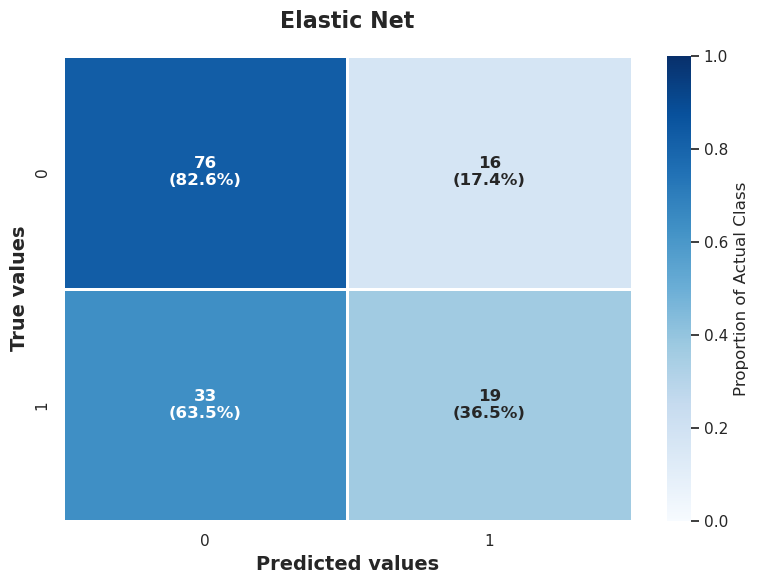

In [86]:
# Compute predictions for the test set
y_pred_EN = optimized_EN.predict(X_test)

# Display confusion matrix
plot_confusion_matrix(y_true=y_test, y_pred=y_pred_EN, 
        title="Elastic Net", output_dir=results_path, file_prefix="EN")

Check the overfitting:

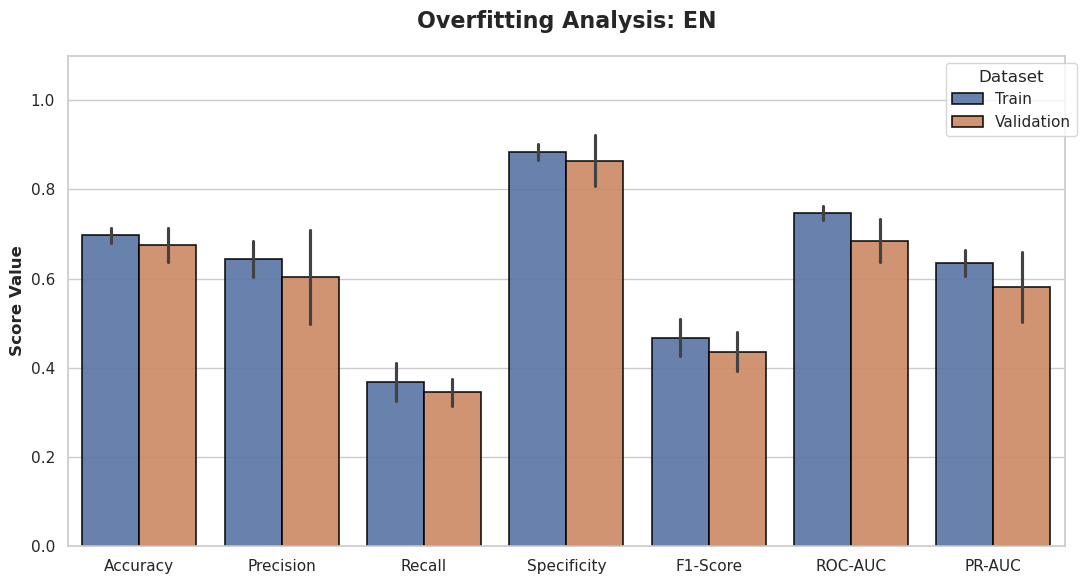

In [87]:
plot_overfitting_bars(cv_results_EN, model_name="EN", output_dir=results_path)

### Support Vector Machine


Set up the pipeline and the parameter distributions:

In [88]:
# Hyperparameters search space
params_dist_SVM = {
    'clf__C': FloatDistribution(1e-5, 1e4, log=True),
    'clf__kernel': CategoricalDistribution(['linear', 'rbf', 'poly', 'sigmoid']),
    'clf__gamma': CategoricalDistribution(['scale', 'auto']),
    'clf__degree': IntDistribution(2, 6),
    'clf__class_weight': CategoricalDistribution([None, 'balanced'])
}

# Get preprocessor
preprocessor_SVM = get_geom_preprocessor(X_train)

# Full pipeline
pipe_SVM = Pipeline(steps=[
    ('preprocessor', preprocessor_SVM),
    ('clf', SVC(random_state=seed))
])

Train and optimize the model:

In [89]:
(optimized_SVM, 
cv_results_SVM,
tpr_SVM, fpr_SVM,
precs_SVM, recs_SVM) = optimize_model_optuna_search(pipe_SVM, params_dist_SVM, 
                                    X_train, y_train, X_test, y_test, 
                                    metrics_dict=scoring_dict,
                                    cv=my_cv)

Starting hyperparameter optimization...


/workspaces/TFM/src/models/training_and_evaluation.py:83: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Show hyperparameters to check if the distributions are wide enough:

In [90]:
save_model(optimized_SVM, results_path)

,Hyperparameter,Optimal Value
1,C,0.523646
2,break_ties,False
3,cache_size,200
4,coef0,0.0
5,decision_function_shape,ovr
6,degree,4
7,gamma,auto
8,kernel,linear
9,max_iter,-1
10,probability,False


Check the confusion matrix:

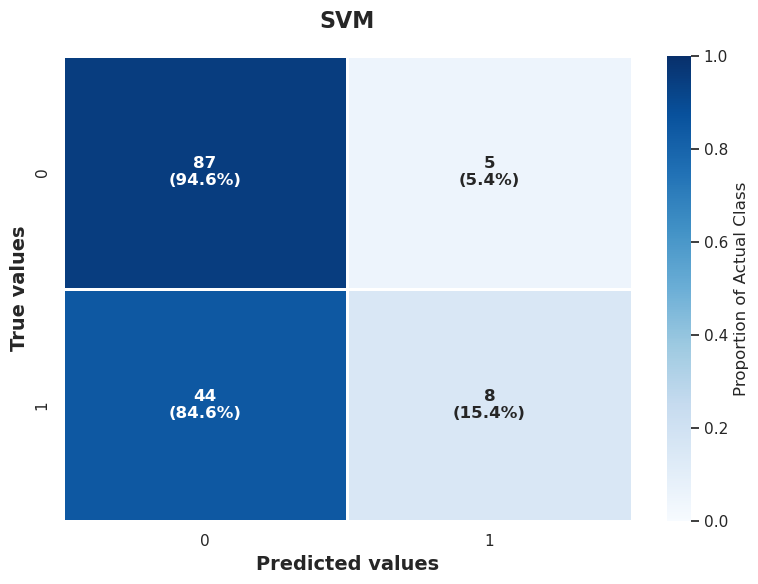

In [91]:
# Compute predictions for the test set
y_pred_SVM = optimized_SVM.predict(X_test)

# Display confusion matrix
plot_confusion_matrix(y_true=y_test, y_pred=y_pred_SVM, 
        title="SVM", output_dir=results_path, file_prefix="SVM")

Check the overfitting:

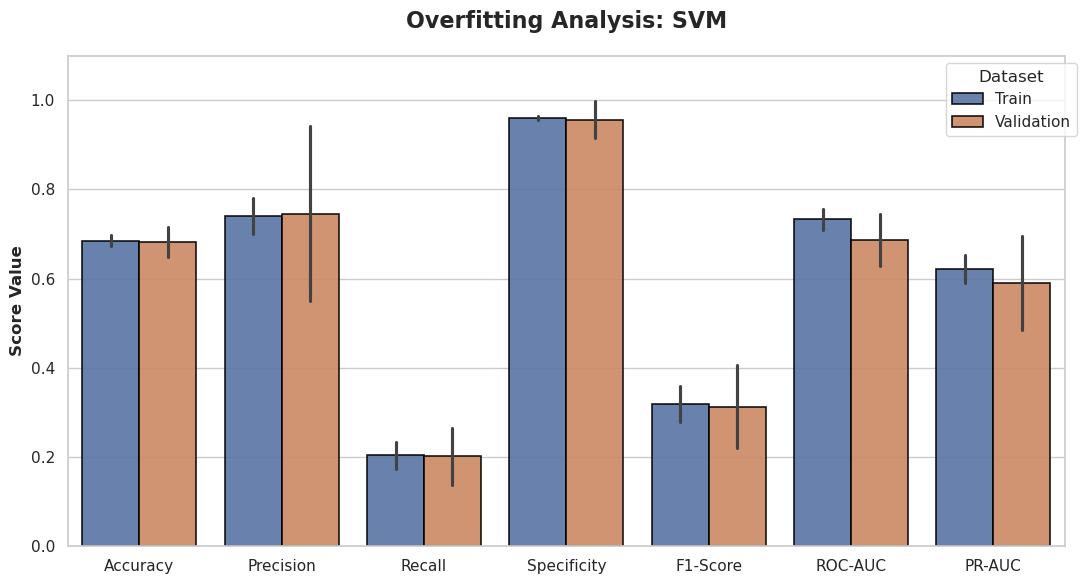

In [92]:
plot_overfitting_bars(cv_results_SVM, model_name="SVM", output_dir=results_path)

### Random Forest

Set up the pipeline and the parameters distributions:

In [93]:
# Hyperparameters search space
params_dist_RF = {
    'clf__n_estimators': IntDistribution(20, 300),
    'clf__max_depth': IntDistribution(2, 32),
    'clf__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'clf__min_samples_split': IntDistribution(2, 20),
    'clf__criterion': CategoricalDistribution(['gini', 'entropy']),
    'clf__class_weight': CategoricalDistribution([None, 'balanced', 'balanced_subsample'])
}

# Get the preprocessor
preprocessor_RF = get_bagg_preprocessor(X_train)

# Full pipeline
pipe_RF = Pipeline(steps=[
    ('preprocessor', preprocessor_RF),
    ('clf', RandomForestClassifier(random_state=seed))
])

Train and optimize the model:

In [94]:
(optimized_RF, 
cv_results_RF,
tpr_RF, fpr_RF,
precs_RF, recs_RF) = optimize_model_optuna_search(pipe_RF, params_dist_RF, 
                                                X_train, y_train, X_test, y_test, 
                                                metrics_dict=scoring_dict,
                                                cv=my_cv)

Starting hyperparameter optimization...


/workspaces/TFM/src/models/training_and_evaluation.py:83: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Show hyperparameters to check if the distributions are wide enough:

In [95]:
save_model(optimized_RF, results_path)

,Hyperparameter,Optimal Value
1,bootstrap,True
2,ccp_alpha,0.0
3,criterion,gini
4,max_depth,23
5,max_features,log2
6,min_impurity_decrease,0.0
7,min_samples_leaf,1
8,min_samples_split,19
9,min_weight_fraction_leaf,0.0
10,n_estimators,29


Check the confusion matrix:

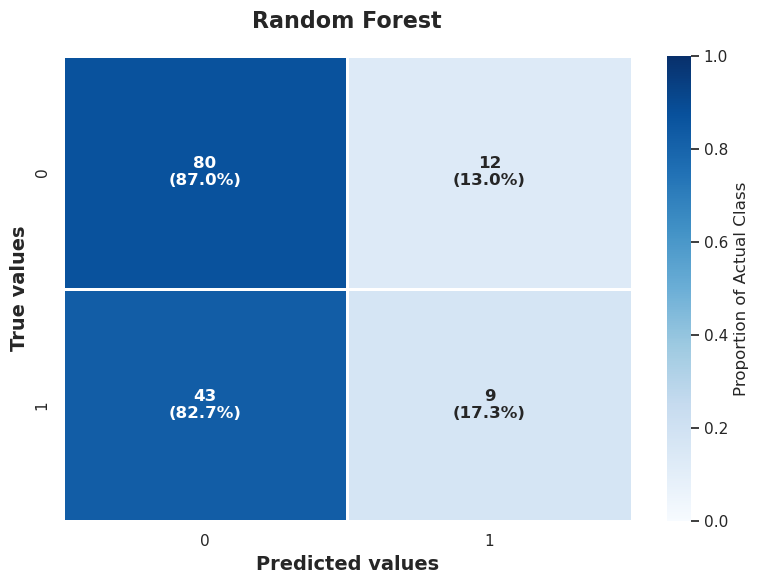

In [96]:
# Compute predictions for the test set
y_pred_RF = optimized_RF.predict(X_test)

# Display confusion matrix
plot_confusion_matrix(y_true=y_test, y_pred=y_pred_RF, 
        title="Random Forest", output_dir=results_path, file_prefix="RF")

Check the overfitting:

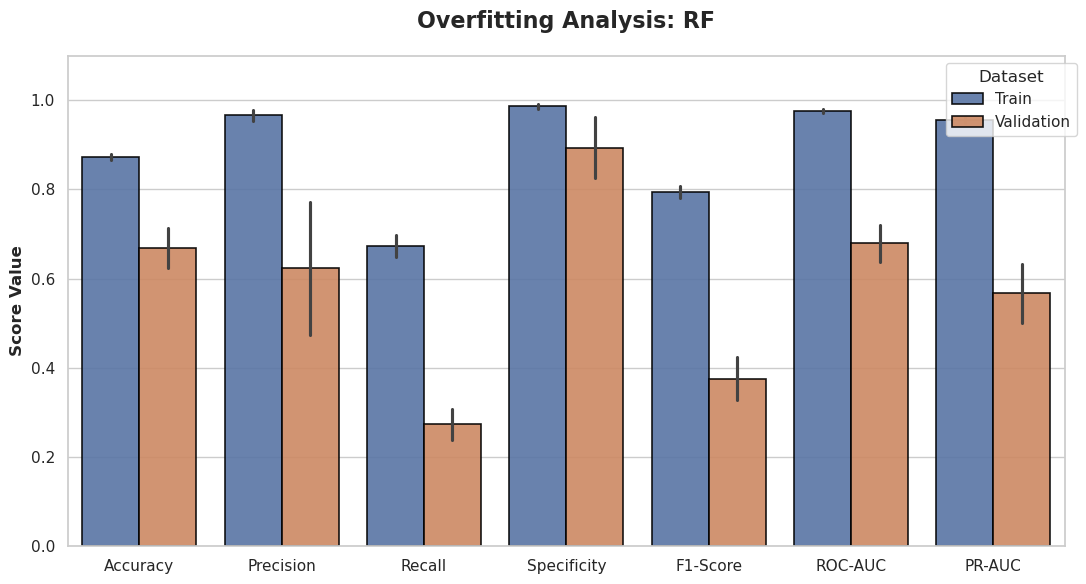

In [97]:
plot_overfitting_bars(cv_results_RF, model_name="RF", output_dir=results_path)

### Extreme Gradient Boosting

Set up the pipeline and the parameters distributions:

In [98]:
# Hyperparameters search space
params_dist_XGB = {
    'clf__n_estimators': IntDistribution(20, 300),
    'clf__max_depth': IntDistribution(3, 10),
    'clf__learning_rate': FloatDistribution(0.01, 0.3),
    
    'clf__subsample': FloatDistribution(0.4, 0.6),
    'clf__colsample_bytree': FloatDistribution(0.4, 0.6),
    
    # Regularization parameters:
    'clf__reg_alpha': FloatDistribution(0, 10),
    'clf__reg_lambda': FloatDistribution(1, 10)
}

# Get the preprocessor
preprocessor_XGB = get_boost_preprocessor(X_train)

# Full pipeline
pipe_XGB = Pipeline(steps=[
    ('preprocessor', preprocessor_XGB),
    ('clf', XGBClassifier(random_state=seed,
                        scale_pos_weight=ratio, 
                        eval_metric='logloss'))
])

Train and optimize the model:

In [99]:
(optimized_XGB, 
cv_results_XGB,
tpr_XGB, fpr_XGB,
precs_XGB, recs_XGB) = optimize_model_optuna_search(pipe_XGB, params_dist_XGB,
                                                X_train, y_train, X_test, y_test,
                                                metrics_dict=scoring_dict,
                                                cv=my_cv,
                                                seed=seed)

Starting hyperparameter optimization...


/workspaces/TFM/src/models/training_and_evaluation.py:83: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(


Evaluating on the training set...
Evaluating on the test set...


Show hyperparameters to check if the distributions are wide enough:

In [100]:
save_model(optimized_XGB, results_path)

,Hyperparameter,Optimal Value
1,objective,binary:logistic
2,colsample_bytree,0.537461
3,enable_categorical,False
4,eval_metric,logloss
5,learning_rate,0.266736
6,max_depth,10
7,n_estimators,281
8,random_state,42
9,reg_alpha,9.324653
10,reg_lambda,3.285584


Check the confusion matrix:

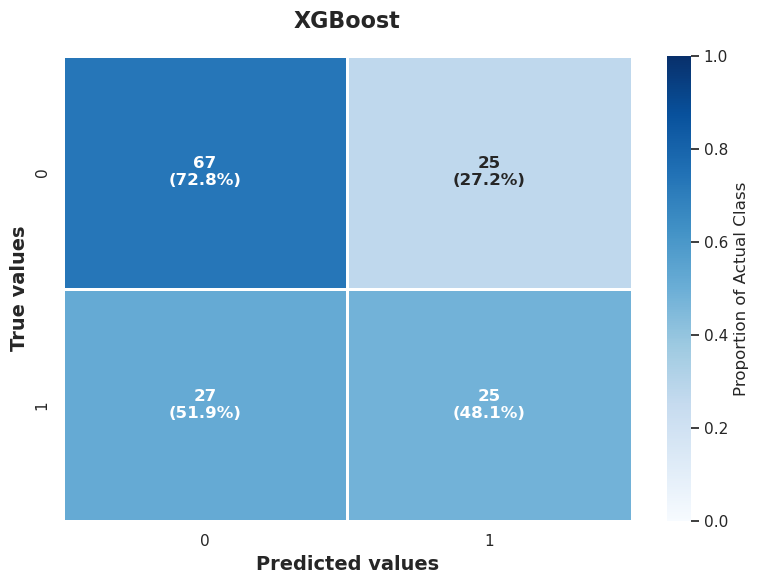

In [101]:
# Compute predictions for the test set
y_pred_XGB = optimized_XGB.predict(X_test)

# Display confusion matrix
plot_confusion_matrix(y_true=y_test, y_pred=y_pred_XGB, 
        title="XGBoost", output_dir=results_path, file_prefix="XGB")

Check the overfitting:

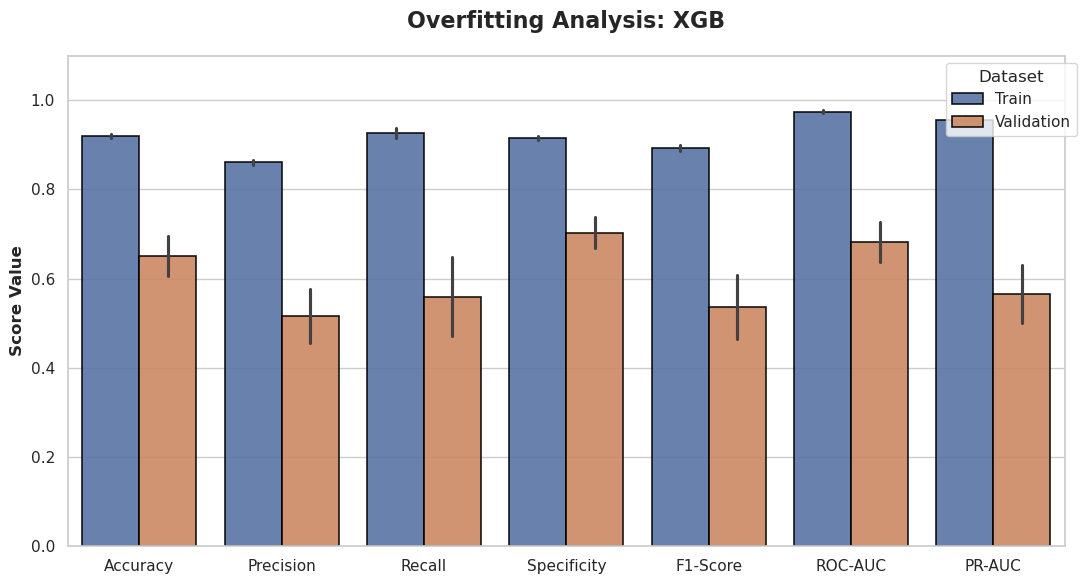

In [102]:
plot_overfitting_bars(cv_results_XGB, model_name="XGB", output_dir=results_path)

## Save results

In [103]:
models = ["Elastic Net", "SVM", "Random Forest", "XGBoost"]

models_dict = {
    "Elastic Net": cv_results_EN,
    "SVM": cv_results_SVM,
    "Random Forest": cv_results_RF,
    "XGBoost": cv_results_XGB
}

### Main metrics

In [104]:
results = save_metrics_results(models_dict=models_dict, output_dir=results_path)

results.head()

,Model,Metric,Dataset,Score
0,Elastic Net,Accuracy,Train,0.717391
1,Elastic Net,Accuracy,Validation,0.655172
2,Elastic Net,Accuracy,Train,0.709328
3,Elastic Net,Accuracy,Validation,0.617391
4,Elastic Net,Accuracy,Train,0.691974


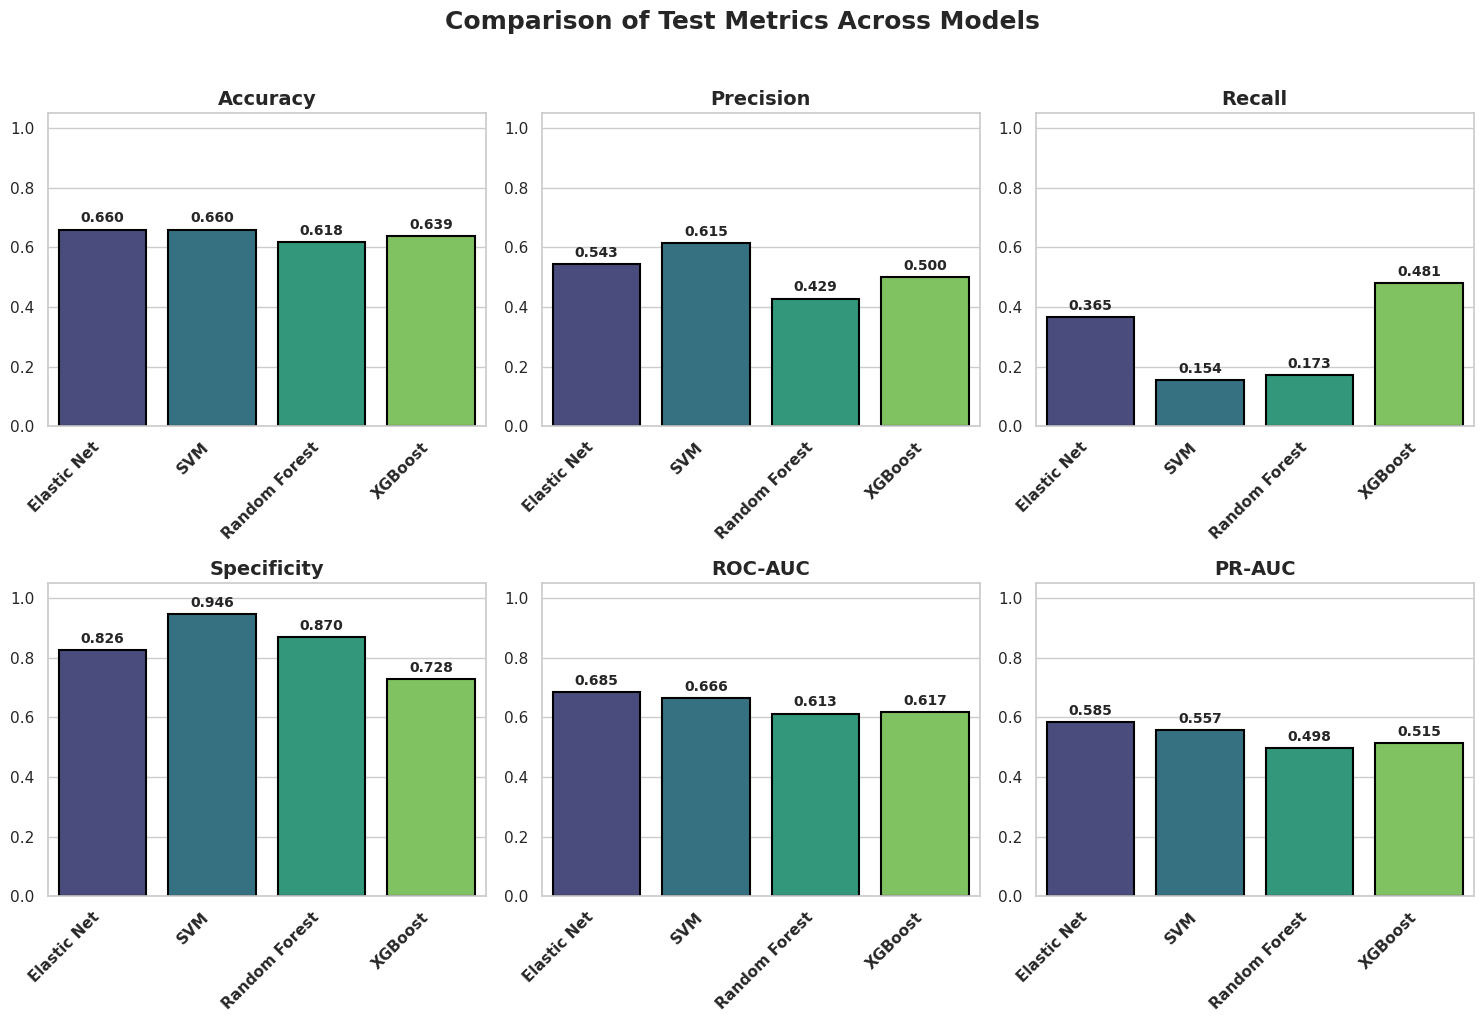

In [105]:
plot_metrics_bars(results, 
                metrics=['Accuracy', 'Precision', 'Recall', 'Specificity', 'ROC-AUC', 'PR-AUC'],
                output_dir=results_path)

### ROC and PR curves

Join the metrics into a csv file:

In [106]:
# Save the false/true positive rates values into a csv
fpr = [fpr_EN, fpr_SVM, fpr_RF, fpr_XGB]
tpr = [tpr_EN, tpr_SVM, tpr_RF, tpr_XGB]

roc_results = save_curves_results(models, fpr, tpr, curve_type='roc', 
                                output_dir=results_path)

# Save the precision and recall values for the PR curves into a csv
precs = [precs_EN, precs_SVM, precs_RF, precs_XGB]
recs = [recs_EN, recs_SVM, recs_RF, recs_XGB]

pr_results = save_curves_results(models, recs, precs, curve_type='pr', 
                                output_dir=results_path)

Plot ROC curves:

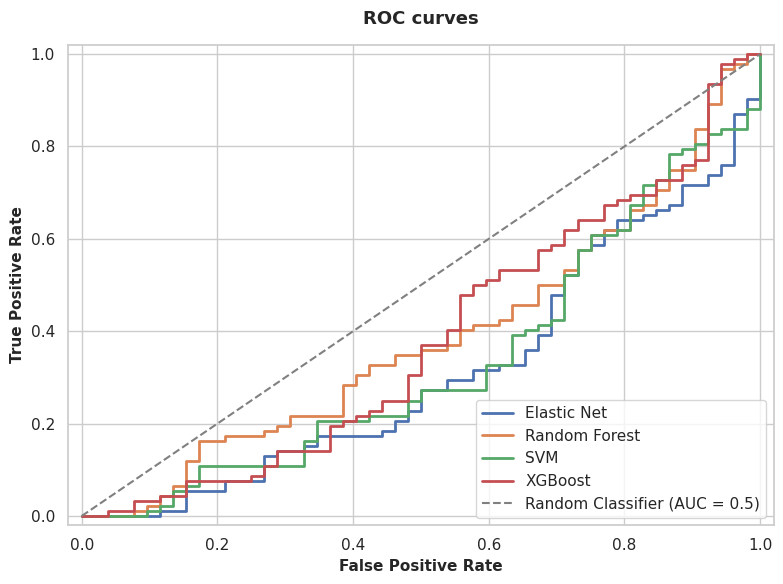

In [107]:
plot_model_curves(roc_results, 
                x_col='False Positive Rate', y_col='True Positive Rate', 
                curve_type='roc', title="ROC curves",
                output_dir=results_path)

Plot PR curves:

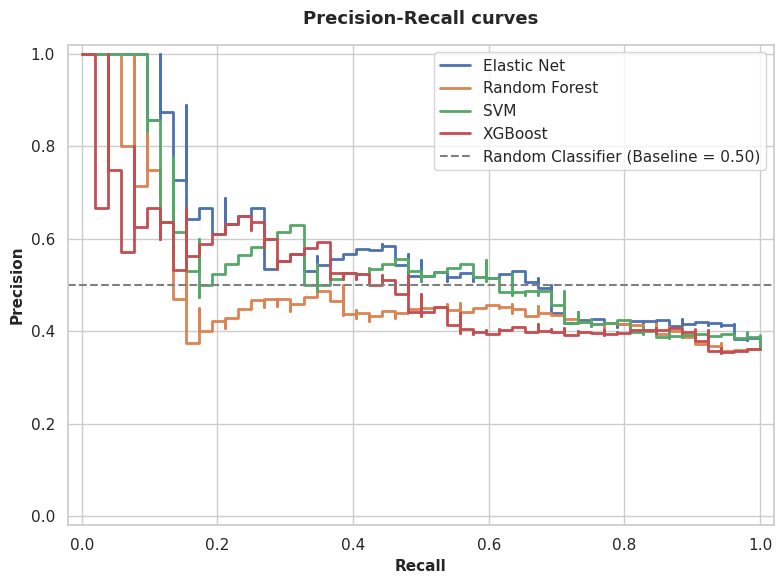

In [108]:
plot_model_curves(pr_results, 
                x_col='Recall', y_col='Precision', 
                curve_type='pr', title="Precision-Recall curves",
                output_dir=results_path)